In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

This notebook contains visual analysis of the Open-Meteo mart dataset.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving mart_daily_2026-05-27_18-50-20.csv to mart_daily_2026-05-27_18-50-20.csv


In [4]:
import pandas as pd

df = pd.read_csv("mart_daily_2026-05-27_18-50-20.csv")

print(df.shape)

df.head()

(7, 10)


,date,city_id,city_name,country_code,timezone,t_mean,t_max,precipitation_sum,rainy_hours,wind_speed_max
0,2024-05-01,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,17.133333,19.9,37.3,18,26.5
1,2024-05-02,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,14.762500,19.9,6.8,7,26.9
2,2024-05-03,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,15.800000,21.9,0.0,0,27.7
3,2024-05-04,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,18.829167,26.5,0.0,0,22.1
4,2024-05-05,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,19.787500,26.3,0.0,0,36.4


In [5]:
df.dtypes

,0
date,object
city_id,object
city_name,object
country_code,object
timezone,object
t_mean,float64
t_max,float64
precipitation_sum,float64
rainy_hours,int64
wind_speed_max,float64


In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.dtypes

,0
date,datetime64[ns]
city_id,object
city_name,object
country_code,object
timezone,object
t_mean,float64
t_max,float64
precipitation_sum,float64
rainy_hours,int64
wind_speed_max,float64


The date column was converted to datetime to ensure correct chronological plotting.

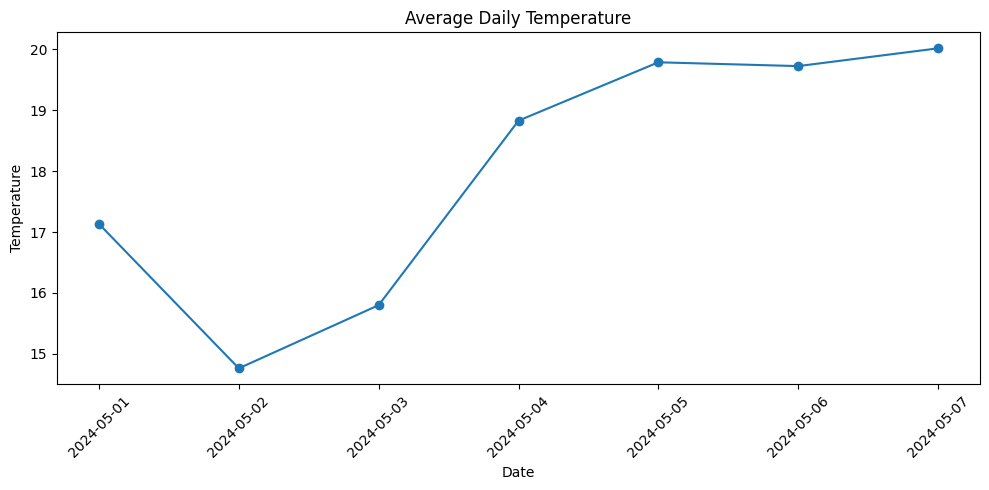

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["date"],
    df["t_mean"],
    marker="o",
)

plt.title("Average Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("week7_timeseries.png")

plt.show()

Average daily temperature changes gradually during the observed period.

The distribution of average daily temperature was analyzed using a histogram.

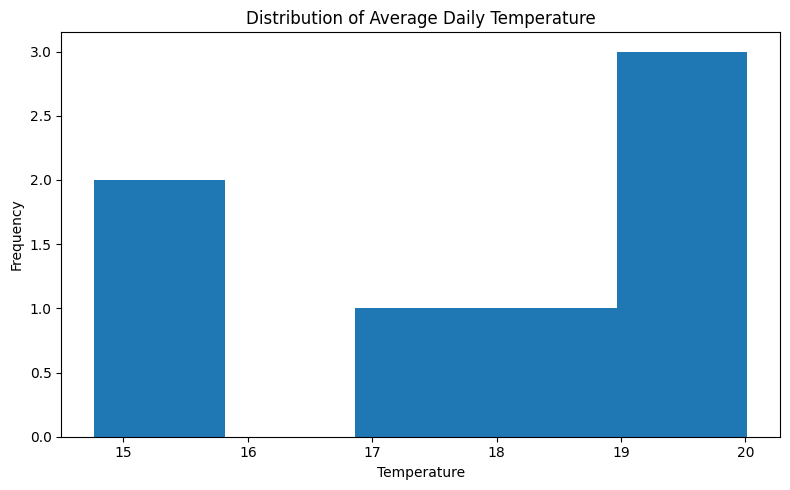

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["t_mean"],
    bins=5,
)

plt.title("Distribution of Average Daily Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("week7_distribution.png")

plt.show()

The temperature distribution is relatively compact because the dataset covers only one week.

Daily precipitation totals were ranked to identify the rainiest days.

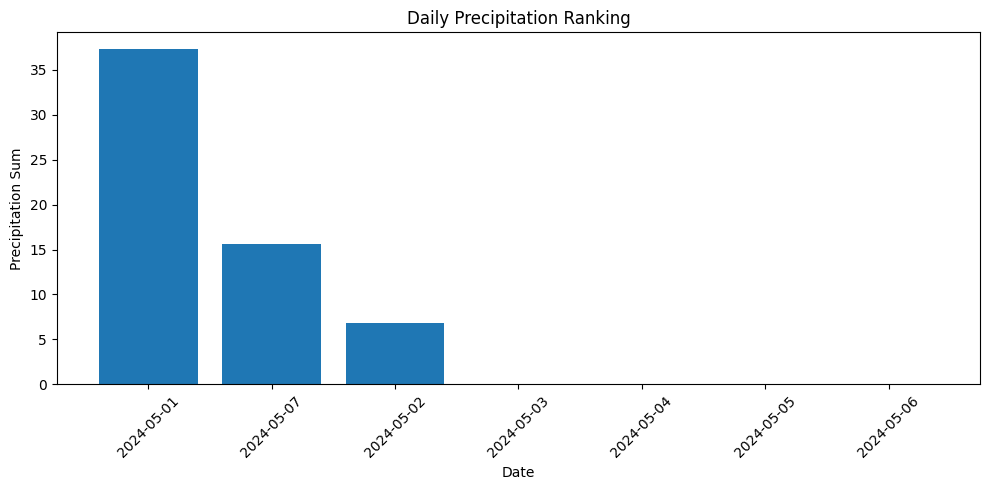

In [12]:
ranking_df = df.sort_values(
    "precipitation_sum",
    ascending=False,
)

plt.figure(figsize=(10, 5))

plt.bar(
    ranking_df["date"].astype(str),
    ranking_df["precipitation_sum"],
)

plt.title("Daily Precipitation Ranking")
plt.xlabel("Date")
plt.ylabel("Precipitation Sum")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("week7_ranking.png")

plt.show()

The highest precipitation was observed on 2024-05-01.